# Computing correlations between extracted features to remove highly correlated ones

In [1]:
import numpy as np
import pandas as pd

from clustering_utils import run_dbscan_clustering, plot_dbscan_panels
import random
from sklearn.preprocessing import StandardScaler
import umap

In [2]:
df = pd.read_csv("features.csv")

In [3]:
df

,Unnamed: 0,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,...,N2,N3,REM,%N1,%N2,%N3,%REM,dataset,file,UNS
0,0,0.065376,0.031159,0.705446,0.013014,0.015420,0.169585,96.486040,0.062912,0.033877,...,125.0,110.0,62.5,8.8821,38.2848,33.6907,19.1424,sc,D:/AI medical course/sleep-cassette/preprocess...,NaN
1,1,0.123991,0.076347,0.501876,0.030060,0.036057,0.231669,104.874471,0.056981,0.042399,...,186.5,148.5,107.5,6.2500,39.5127,31.4619,22.7754,sc,D:/AI medical course/sleep-cassette/preprocess...,0.5
2,2,0.024900,0.025434,0.875024,0.007547,0.008600,0.058495,57.880545,0.037089,0.035834,...,281.0,52.5,85.0,11.5222,59.4080,11.0994,17.9704,sc,D:/AI medical course/sleep-cassette/preprocess...,NaN
3,3,0.029998,0.020352,0.866908,0.006435,0.008039,0.068268,82.284571,0.042276,0.039619,...,330.0,48.0,88.0,8.9844,64.4531,9.3750,17.1875,sc,D:/AI medical course/sleep-cassette/preprocess...,NaN
4,4,0.034776,0.029140,0.850444,0.011643,0.012658,0.061340,59.663533,0.042456,0.043798,...,272.5,47.5,81.5,10.4794,60.7581,10.5909,18.1717,sc,D:/AI medical course/sleep-cassette/preprocess...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,192,0.098657,0.093278,0.676409,0.022615,0.037730,0.071312,263.191276,0.102998,0.101034,...,189.0,99.0,72.0,15.7895,44.2105,23.1579,16.8421,st,D:/AI medical course/sleep-telemetry/preproces...,NaN
193,193,0.179019,0.104741,0.439619,0.031685,0.053162,0.191775,69.158319,0.107186,0.044397,...,219.0,1.0,115.5,23.9229,49.6599,0.2268,26.1905,st,D:/AI medical course/sleep-telemetry/preproces...,NaN
194,194,0.222309,0.108403,0.390920,0.026005,0.064567,0.187797,45.861339,0.109298,0.055336,...,237.5,0.0,100.0,22.0554,54.8499,0.0000,23.0947,st,D:/AI medical course/sleep-telemetry/preproces...,NaN
195,195,0.052461,0.057843,0.738047,0.023495,0.023833,0.104322,118.493579,0.049777,0.037316,...,335.0,22.5,118.5,4.2254,67.4044,4.5272,23.8431,st,D:/AI medical course/sleep-telemetry/preproces...,1.5


In [4]:
df.columns.tolist()

['Unnamed: 0',
 'EEG Fpz-Cz_0_Alpha',
 'EEG Fpz-Cz_0_Beta',
 'EEG Fpz-Cz_0_Delta',
 'EEG Fpz-Cz_0_Gamma',
 'EEG Fpz-Cz_0_Sigma',
 'EEG Fpz-Cz_0_Theta',
 'EEG Fpz-Cz_0_TotalAbsPow',
 'EEG Fpz-Cz_1_Alpha',
 'EEG Fpz-Cz_1_Beta',
 'EEG Fpz-Cz_1_Delta',
 'EEG Fpz-Cz_1_Gamma',
 'EEG Fpz-Cz_1_Sigma',
 'EEG Fpz-Cz_1_Theta',
 'EEG Fpz-Cz_1_TotalAbsPow',
 'EEG Fpz-Cz_2_Alpha',
 'EEG Fpz-Cz_2_Beta',
 'EEG Fpz-Cz_2_Delta',
 'EEG Fpz-Cz_2_Gamma',
 'EEG Fpz-Cz_2_Sigma',
 'EEG Fpz-Cz_2_Theta',
 'EEG Fpz-Cz_2_TotalAbsPow',
 'EEG Fpz-Cz_3_Alpha',
 'EEG Fpz-Cz_3_Beta',
 'EEG Fpz-Cz_3_Delta',
 'EEG Fpz-Cz_3_Gamma',
 'EEG Fpz-Cz_3_Sigma',
 'EEG Fpz-Cz_3_Theta',
 'EEG Fpz-Cz_3_TotalAbsPow',
 'EEG Fpz-Cz_4_Alpha',
 'EEG Fpz-Cz_4_Beta',
 'EEG Fpz-Cz_4_Delta',
 'EEG Fpz-Cz_4_Gamma',
 'EEG Fpz-Cz_4_Sigma',
 'EEG Fpz-Cz_4_Theta',
 'EEG Fpz-Cz_4_TotalAbsPow',
 'EEG Pz-Oz_0_Alpha',
 'EEG Pz-Oz_0_Beta',
 'EEG Pz-Oz_0_Delta',
 'EEG Pz-Oz_0_Gamma',
 'EEG Pz-Oz_0_Sigma',
 'EEG Pz-Oz_0_Theta',
 'EEG Pz-Oz_0_TotalAbsPo

In [5]:
hyp_features = ['SPT',
 'WASO',
 'TST',
 'SME',
 'SFI',
 'Lat_REM',
 'WAKE',
 'N1',
 'N2',
 'N3',
 'REM',
 '%N1',
 '%N2',
 '%N3',
 '%REM']

signal_features = ['EEG Fpz-Cz_0_Alpha',
 'EEG Fpz-Cz_0_Beta',
 'EEG Fpz-Cz_0_Delta',
 'EEG Fpz-Cz_0_Gamma',
 'EEG Fpz-Cz_0_Sigma',
 'EEG Fpz-Cz_0_Theta',
 'EEG Fpz-Cz_0_TotalAbsPow',
 'EEG Fpz-Cz_1_Alpha',
 'EEG Fpz-Cz_1_Beta',
 'EEG Fpz-Cz_1_Delta',
 'EEG Fpz-Cz_1_Gamma',
 'EEG Fpz-Cz_1_Sigma',
 'EEG Fpz-Cz_1_Theta',
 'EEG Fpz-Cz_1_TotalAbsPow',
 'EEG Fpz-Cz_2_Alpha',
 'EEG Fpz-Cz_2_Beta',
 'EEG Fpz-Cz_2_Delta',
 'EEG Fpz-Cz_2_Gamma',
 'EEG Fpz-Cz_2_Sigma',
 'EEG Fpz-Cz_2_Theta',
 'EEG Fpz-Cz_2_TotalAbsPow',
 'EEG Fpz-Cz_3_Alpha',
 'EEG Fpz-Cz_3_Beta',
 'EEG Fpz-Cz_3_Delta',
 'EEG Fpz-Cz_3_Gamma',
 'EEG Fpz-Cz_3_Sigma',
 'EEG Fpz-Cz_3_Theta',
 'EEG Fpz-Cz_3_TotalAbsPow',
 'EEG Fpz-Cz_4_Alpha',
 'EEG Fpz-Cz_4_Beta',
 'EEG Fpz-Cz_4_Delta',
 'EEG Fpz-Cz_4_Gamma',
 'EEG Fpz-Cz_4_Sigma',
 'EEG Fpz-Cz_4_Theta',
 'EEG Fpz-Cz_4_TotalAbsPow',
 'EEG Pz-Oz_0_Alpha',
 'EEG Pz-Oz_0_Beta',
 'EEG Pz-Oz_0_Delta',
 'EEG Pz-Oz_0_Gamma',
 'EEG Pz-Oz_0_Sigma',
 'EEG Pz-Oz_0_Theta',
 'EEG Pz-Oz_0_TotalAbsPow',
 'EEG Pz-Oz_1_Alpha',
 'EEG Pz-Oz_1_Beta',
 'EEG Pz-Oz_1_Delta',
 'EEG Pz-Oz_1_Gamma',
 'EEG Pz-Oz_1_Sigma',
 'EEG Pz-Oz_1_Theta',
 'EEG Pz-Oz_1_TotalAbsPow',
 'EEG Pz-Oz_2_Alpha',
 'EEG Pz-Oz_2_Beta',
 'EEG Pz-Oz_2_Delta',
 'EEG Pz-Oz_2_Gamma',
 'EEG Pz-Oz_2_Sigma',
 'EEG Pz-Oz_2_Theta',
 'EEG Pz-Oz_2_TotalAbsPow',
 'EEG Pz-Oz_3_Alpha',
 'EEG Pz-Oz_3_Beta',
 'EEG Pz-Oz_3_Delta',
 'EEG Pz-Oz_3_Gamma',
 'EEG Pz-Oz_3_Sigma',
 'EEG Pz-Oz_3_Theta',
 'EEG Pz-Oz_3_TotalAbsPow',
 'EEG Pz-Oz_4_Alpha',
 'EEG Pz-Oz_4_Beta',
 'EEG Pz-Oz_4_Delta',
 'EEG Pz-Oz_4_Gamma',
 'EEG Pz-Oz_4_Sigma',
 'EEG Pz-Oz_4_Theta',
 'EEG Pz-Oz_4_TotalAbsPow',
 'EEG Fpz-Cz_SW_density',
 'EEG Pz-Oz_SW_density',
 'EEG Fpz-Cz_SP_density',
 'EEG Pz-Oz_SP_density',
 'EMG_submental_RMS_mean_W',
 'EMG_submental_RMS_std_W',
 'EMG_submental_RMS_mean_N1',
 'EMG_submental_RMS_std_N1',
 'EMG_submental_RMS_mean_N2',
 'EMG_submental_RMS_std_N2',
 'EMG_submental_RMS_mean_N3',
 'EMG_submental_RMS_std_N3',
 'EMG_submental_RMS_mean_R',
 'EMG_submental_RMS_std_R',
 'EMG_submental_RMS_mean_all',
 'EMG_submental_RMS_std_all']

In [6]:
hypno_feature_df = df[hyp_features]
hypno_feature_df

,SPT,WASO,TST,SME,SFI,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
0,360.5,34.0,326.5,90.5687,0.9188,89.0,34.0,29.0,125.0,110.0,62.5,8.8821,38.2848,33.6907,19.1424
1,504.0,31.5,472.0,93.6508,1.3347,66.0,31.5,29.5,186.5,148.5,107.5,6.2500,39.5127,31.4619,22.7754
2,491.5,18.5,473.0,96.2360,0.8245,119.5,18.5,54.5,281.0,52.5,85.0,11.5222,59.4080,11.0994,17.9704
3,533.0,21.0,512.0,96.0600,0.8789,98.5,21.0,46.0,330.0,48.0,88.0,8.9844,64.4531,9.3750,17.1875
4,452.5,4.0,448.5,99.1160,0.4682,79.5,4.0,47.0,272.5,47.5,81.5,10.4794,60.7581,10.5909,18.1717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,475.5,48.0,427.5,89.9054,1.7544,78.0,48.0,67.5,189.0,99.0,72.0,15.7895,44.2105,23.1579,16.8421
193,481.5,40.5,441.0,91.5888,1.7687,81.5,40.5,105.5,219.0,1.0,115.5,23.9229,49.6599,0.2268,26.1905
194,462.0,29.0,433.0,93.7229,1.5242,59.5,29.0,95.5,237.5,0.0,100.0,22.0554,54.8499,0.0000,23.0947
195,507.5,9.0,497.0,97.9310,0.4829,98.0,9.0,21.0,335.0,22.5,118.5,4.2254,67.4044,4.5272,23.8431


In [7]:
signal_feature_df = df[signal_features]
signal_feature_df

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,EMG_submental_RMS_mean_N1,EMG_submental_RMS_std_N1,EMG_submental_RMS_mean_N2,EMG_submental_RMS_std_N2,EMG_submental_RMS_mean_N3,EMG_submental_RMS_std_N3,EMG_submental_RMS_mean_R,EMG_submental_RMS_std_R,EMG_submental_RMS_mean_all,EMG_submental_RMS_std_all
0,0.065376,0.031159,0.705446,0.013014,0.015420,0.169585,96.486040,0.062912,0.033877,0.667959,...,0.976496,0.432397,0.823287,0.381184,0.909823,0.369457,1.433877,0.102165,0.979130,0.428159
1,0.123991,0.076347,0.501876,0.030060,0.036057,0.231669,104.874471,0.056981,0.042399,0.656781,...,1.177773,0.520964,0.923139,0.582368,0.940718,0.589042,1.219083,0.138128,1.070608,0.575462
2,0.024900,0.025434,0.875024,0.007547,0.008600,0.058495,57.880545,0.037089,0.035834,0.790213,...,1.262309,0.533267,0.761802,0.399394,0.735873,0.137409,0.799950,0.135181,0.854919,0.427737
3,0.029998,0.020352,0.866908,0.006435,0.008039,0.068268,82.284571,0.042276,0.039619,0.749222,...,1.545480,0.630405,1.103590,0.518797,0.995220,0.508083,1.118095,0.403696,1.169451,0.556420
4,0.034776,0.029140,0.850444,0.011643,0.012658,0.061340,59.663533,0.042456,0.043798,0.765950,...,1.364754,0.276932,1.104965,0.492213,0.904932,0.581369,1.566745,0.064123,1.197470,0.482131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,0.098657,0.093278,0.676409,0.022615,0.037730,0.071312,263.191276,0.102998,0.101034,0.559486,...,7.890901,10.883513,6.793881,13.385499,8.701561,8.453699,7.938219,6.381248,11.213019,21.798467
193,0.179019,0.104741,0.439619,0.031685,0.053162,0.191775,69.158319,0.107186,0.044397,0.588099,...,5.849506,6.005042,3.299567,2.276412,2.294297,0.761191,2.543819,2.181538,5.087611,7.549272
194,0.222309,0.108403,0.390920,0.026005,0.064567,0.187797,45.861339,0.109298,0.055336,0.584344,...,80.875457,137.630866,29.471108,99.657446,NaN,NaN,41.024185,79.406852,62.181801,163.842256
195,0.052461,0.057843,0.738047,0.023495,0.023833,0.104322,118.493579,0.049777,0.037316,0.730012,...,14.596103,17.589484,7.791796,10.502735,6.237054,1.986978,9.522706,8.575624,8.736300,10.792434


In [8]:
all_features_df = df.drop(columns=['dataset', 'file', 'UNS', 'Unnamed: 0'])

In [9]:
all_features_df

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
0,0.065376,0.031159,0.705446,0.013014,0.015420,0.169585,96.486040,0.062912,0.033877,0.667959,...,89.0,34.0,29.0,125.0,110.0,62.5,8.8821,38.2848,33.6907,19.1424
1,0.123991,0.076347,0.501876,0.030060,0.036057,0.231669,104.874471,0.056981,0.042399,0.656781,...,66.0,31.5,29.5,186.5,148.5,107.5,6.2500,39.5127,31.4619,22.7754
2,0.024900,0.025434,0.875024,0.007547,0.008600,0.058495,57.880545,0.037089,0.035834,0.790213,...,119.5,18.5,54.5,281.0,52.5,85.0,11.5222,59.4080,11.0994,17.9704
3,0.029998,0.020352,0.866908,0.006435,0.008039,0.068268,82.284571,0.042276,0.039619,0.749222,...,98.5,21.0,46.0,330.0,48.0,88.0,8.9844,64.4531,9.3750,17.1875
4,0.034776,0.029140,0.850444,0.011643,0.012658,0.061340,59.663533,0.042456,0.043798,0.765950,...,79.5,4.0,47.0,272.5,47.5,81.5,10.4794,60.7581,10.5909,18.1717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,0.098657,0.093278,0.676409,0.022615,0.037730,0.071312,263.191276,0.102998,0.101034,0.559486,...,78.0,48.0,67.5,189.0,99.0,72.0,15.7895,44.2105,23.1579,16.8421
193,0.179019,0.104741,0.439619,0.031685,0.053162,0.191775,69.158319,0.107186,0.044397,0.588099,...,81.5,40.5,105.5,219.0,1.0,115.5,23.9229,49.6599,0.2268,26.1905
194,0.222309,0.108403,0.390920,0.026005,0.064567,0.187797,45.861339,0.109298,0.055336,0.584344,...,59.5,29.0,95.5,237.5,0.0,100.0,22.0554,54.8499,0.0000,23.0947
195,0.052461,0.057843,0.738047,0.023495,0.023833,0.104322,118.493579,0.049777,0.037316,0.730012,...,98.0,9.0,21.0,335.0,22.5,118.5,4.2254,67.4044,4.5272,23.8431


In [10]:
corr_matrix = all_features_df.corr().abs()

In [11]:
corr_matrix

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
EEG Fpz-Cz_0_Alpha,1.000000,0.533870,0.825855,0.124997,0.698501,0.584833,0.359860,0.523302,0.126756,0.396290,...,0.271546,0.258924,0.026226,0.115424,0.048280,0.144494,0.007841,0.016744,0.009777,0.054016
EEG Fpz-Cz_0_Beta,0.533870,1.000000,0.849127,0.710608,0.789836,0.248922,0.239033,0.325548,0.629236,0.569912,...,0.001989,0.098984,0.079458,0.031107,0.070421,0.216906,0.091967,0.098194,0.061845,0.200861
EEG Fpz-Cz_0_Delta,0.825855,0.849127,1.000000,0.569699,0.863834,0.662074,0.341142,0.459674,0.341533,0.543559,...,0.091564,0.142834,0.047629,0.058523,0.036842,0.206395,0.068175,0.033919,0.003148,0.151669
EEG Fpz-Cz_0_Gamma,0.124997,0.710608,0.569699,1.000000,0.424372,0.138301,0.033543,0.120684,0.338783,0.327343,...,0.209757,0.152406,0.179749,0.080663,0.136475,0.162669,0.177230,0.091583,0.146447,0.186050
EEG Fpz-Cz_0_Sigma,0.698501,0.789836,0.863834,0.424372,1.000000,0.436027,0.292634,0.441004,0.306212,0.446810,...,0.131642,0.175686,0.044979,0.063430,0.016495,0.186831,0.056412,0.008540,0.034307,0.150799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REM,0.144494,0.216906,0.206395,0.162669,0.186831,0.084230,0.181261,0.260977,0.124110,0.215898,...,0.044481,0.030661,0.223769,0.002532,0.184545,1.000000,0.324629,0.358105,0.081840,0.939464
%N1,0.007841,0.091967,0.068175,0.177230,0.056412,0.021025,0.131599,0.091354,0.038260,0.039689,...,0.112216,0.395275,0.972767,0.218945,0.506690,0.324629,1.000000,0.231809,0.497786,0.341544
%N2,0.016744,0.098194,0.033919,0.091583,0.008540,0.085393,0.029072,0.042943,0.121755,0.087772,...,0.107340,0.062364,0.241961,0.802483,0.562855,0.358105,0.231809,1.000000,0.564396,0.408685
%N3,0.009777,0.061845,0.003148,0.146447,0.034307,0.127238,0.070835,0.023952,0.010424,0.093112,...,0.171335,0.274317,0.487827,0.493719,0.975862,0.081840,0.497786,0.564396,1.000000,0.112185


In [12]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [13]:
upper

,EEG Fpz-Cz_0_Alpha,EEG Fpz-Cz_0_Beta,EEG Fpz-Cz_0_Delta,EEG Fpz-Cz_0_Gamma,EEG Fpz-Cz_0_Sigma,EEG Fpz-Cz_0_Theta,EEG Fpz-Cz_0_TotalAbsPow,EEG Fpz-Cz_1_Alpha,EEG Fpz-Cz_1_Beta,EEG Fpz-Cz_1_Delta,...,Lat_REM,WAKE,N1,N2,N3,REM,%N1,%N2,%N3,%REM
EEG Fpz-Cz_0_Alpha,NaN,0.53387,0.825855,0.124997,0.698501,0.584833,0.359860,0.523302,0.126756,0.396290,...,0.271546,0.258924,0.026226,0.115424,0.048280,0.144494,0.007841,0.016744,0.009777,0.054016
EEG Fpz-Cz_0_Beta,NaN,NaN,0.849127,0.710608,0.789836,0.248922,0.239033,0.325548,0.629236,0.569912,...,0.001989,0.098984,0.079458,0.031107,0.070421,0.216906,0.091967,0.098194,0.061845,0.200861
EEG Fpz-Cz_0_Delta,NaN,NaN,NaN,0.569699,0.863834,0.662074,0.341142,0.459674,0.341533,0.543559,...,0.091564,0.142834,0.047629,0.058523,0.036842,0.206395,0.068175,0.033919,0.003148,0.151669
EEG Fpz-Cz_0_Gamma,NaN,NaN,NaN,NaN,0.424372,0.138301,0.033543,0.120684,0.338783,0.327343,...,0.209757,0.152406,0.179749,0.080663,0.136475,0.162669,0.177230,0.091583,0.146447,0.186050
EEG Fpz-Cz_0_Sigma,NaN,NaN,NaN,NaN,NaN,0.436027,0.292634,0.441004,0.306212,0.446810,...,0.131642,0.175686,0.044979,0.063430,0.016495,0.186831,0.056412,0.008540,0.034307,0.150799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
REM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.324629,0.358105,0.081840,0.939464
%N1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.231809,0.497786,0.341544
%N2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.564396,0.408685
%N3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112185


In [14]:
# Stack and clean
correlations = (upper.stack()
                     .reset_index()
                     .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'}))

# Sort by absolute correlation descending
correlations = correlations.iloc[correlations['Correlation'].abs().argsort()[::-1]]

print(correlations.to_string(index=False))

                 Feature 1                  Feature 2  Correlation
                      WASO                       WAKE     1.000000
         EEG Pz-Oz_2_Gamma          EEG Pz-Oz_3_Gamma     0.989703
                        N3                        %N3     0.975862
                        N1                        %N1     0.972767
   EMG_submental_RMS_std_W  EMG_submental_RMS_std_all     0.968838
          EEG Pz-Oz_3_Beta          EEG Pz-Oz_3_Gamma     0.966475
 EMG_submental_RMS_mean_N2 EMG_submental_RMS_mean_all     0.957666
         EEG Pz-Oz_2_Gamma           EEG Pz-Oz_3_Beta     0.954070
                       SME                       WAKE     0.952489
                      WASO                        SME     0.952489
 EMG_submental_RMS_mean_N3   EMG_submental_RMS_std_N3     0.949622
                       SPT                       WAKE     0.948809
                       SPT                       WASO     0.948809
                       REM                       %REM     0.93

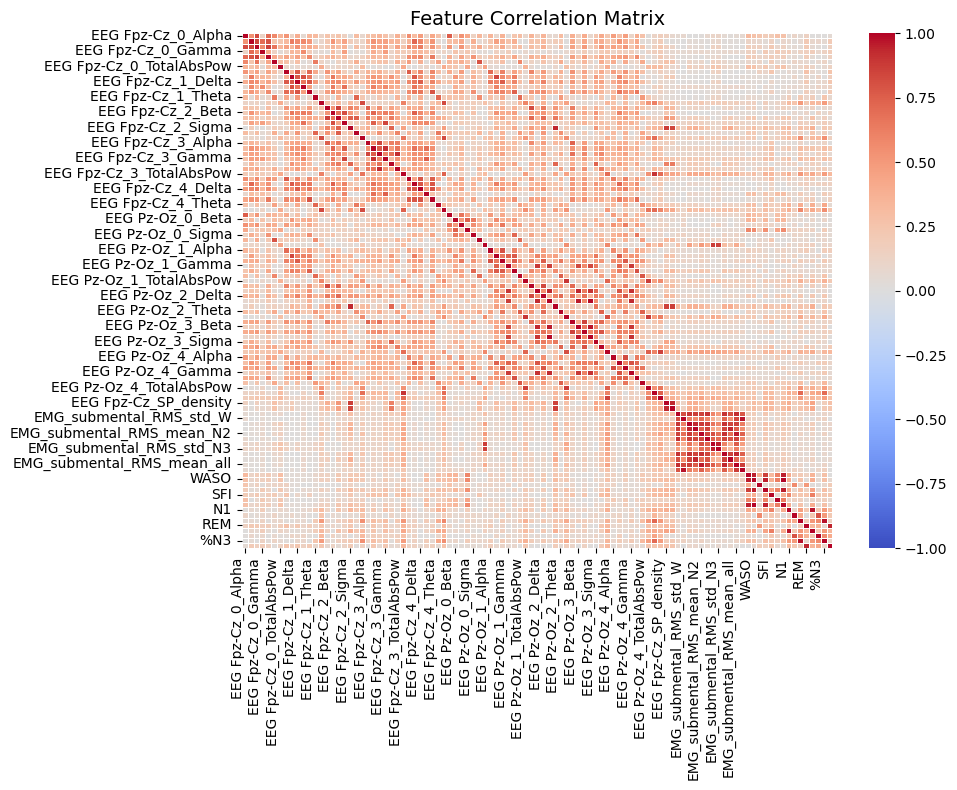

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=False,          # Show correlation values in cells
    cmap="coolwarm",     # Color scheme (blue=negative, red=positive)
    vmin=-1, vmax=1,     # Fix color scale to [-1, 1]
    linewidths=0.5,      # Add gridlines between cells
)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.xticks(rotation=90, ha="right")  # Rotate x labels for readability
plt.tight_layout()
plt.show()

In [16]:
# remove highly correlated features
corr_threshold = 0.7 # need to select threshold - with 0.7 we keep 25 features

to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
selected_features = [col for col in all_features_df.columns if col not in to_drop]
print("correlation filter selected:", selected_features)
print("n =", len(selected_features))

correlation filter selected: ['EEG Fpz-Cz_0_Alpha', 'EEG Fpz-Cz_0_Beta', 'EEG Fpz-Cz_0_Theta', 'EEG Fpz-Cz_0_TotalAbsPow', 'EEG Fpz-Cz_1_Alpha', 'EEG Fpz-Cz_1_Beta', 'EEG Fpz-Cz_1_Theta', 'EEG Fpz-Cz_1_TotalAbsPow', 'EEG Fpz-Cz_2_Alpha', 'EEG Fpz-Cz_2_Beta', 'EEG Fpz-Cz_3_TotalAbsPow', 'EEG Pz-Oz_0_Beta', 'EEG Pz-Oz_0_Delta', 'EEG Pz-Oz_0_Sigma', 'EEG Pz-Oz_0_TotalAbsPow', 'EEG Pz-Oz_1_TotalAbsPow', 'EEG Pz-Oz_4_Alpha', 'EMG_submental_RMS_mean_W', 'SPT', 'TST', 'SFI', 'Lat_REM', 'N1', 'N2', 'REM']
n = 25


In [17]:
# then idea would be to cluster on: 1) hypno_features, 2) signal_features, 3) selected features

## Clustering

In [18]:
random.seed(42)

#### DBSCAN

In [19]:
# Scaling (Feature matrix has minutes, %, ...)
hypno_feature_df_scaled = hypno_feature_df.dropna()
hypno_feature_df_scaled = StandardScaler().fit_transform(hypno_feature_df_scaled)

signal_feature_df_scaled = signal_feature_df.dropna()
signal_feature_df_scaled = StandardScaler().fit_transform(signal_feature_df_scaled)

selected_features_scaled = df[selected_features].dropna()
selected_features_scaled = StandardScaler().fit_transform(selected_features_scaled)

In [20]:
# Dimensionality reduction
hypno_umap = umap.UMAP(n_components=2).fit_transform(hypno_feature_df_scaled)

signal_umap = umap.UMAP(n_components=2).fit_transform(signal_feature_df_scaled)

selected_umap = umap.UMAP(n_components=2).fit_transform(selected_features_scaled)


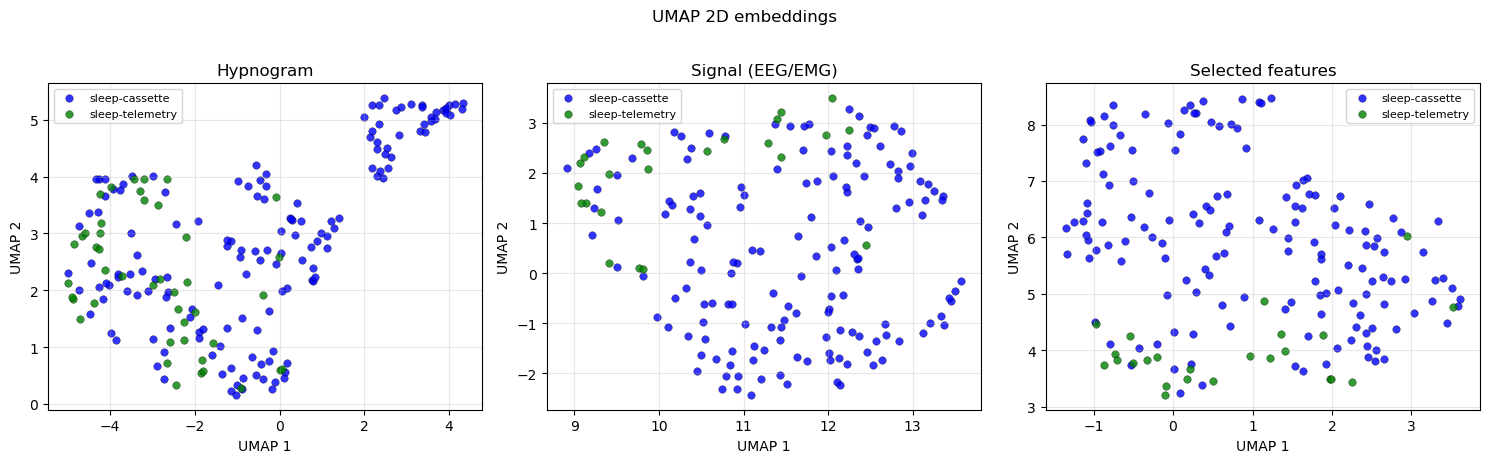

In [21]:
COHORT_COLORS = {"sc": "blue", "st": "green"}
COHORT_LABELS = {"sc": "sleep-cassette", "st": "sleep-telemetry"}
umap_results = [
    (hypno_umap, "Hypnogram", hypno_feature_df),
    (signal_umap, "Signal (EEG/EMG)", signal_feature_df),
    (selected_umap, "Selected features", df[selected_features]),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (coords, name, feat_df) in zip(axes, umap_results):
    coords = np.asarray(coords)
    idx = feat_df.index[: len(coords)]
    cohort = df.loc[idx, "dataset"]
    for key, color in COHORT_COLORS.items():
        mask = cohort.values == key
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=30,
            alpha=0.8,
            c=color,
            label=COHORT_LABELS[key],
            edgecolors="k",
            linewidths=0.25,
        )
    ax.set_title(name)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
fig.suptitle("UMAP 2D embeddings", y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Clustering

hypno_clustered, hypno_labels, hypno_fit = run_dbscan_clustering(
    hypno_umap,
    title="DBSCAN on hypnogram features",
    eps=1.5,
    minPts=5,
)

signal_clustered, signal_labels, signal_fit = run_dbscan_clustering(
    signal_umap,
    title="DBSCAN on EEG features",
    eps=1.5,
    minPts=5,
)
selected_clustered, selected_labels, selected_fit = run_dbscan_clustering(
    selected_umap,
    title="DBSCAN on selected features",
    eps=1.5,
    minPts=5,
)



DBSCAN on hypnogram features
  Clusters (excluding noise): 1
  Noise points: 0
dbscan_label
0    197
Name: count, dtype: int64
DBSCAN on EEG features
  Clusters (excluding noise): 1
  Noise points: 0
dbscan_label
0    177
Name: count, dtype: int64
DBSCAN on selected features
  Clusters (excluding noise): 1
  Noise points: 0
dbscan_label
0    177
Name: count, dtype: int64


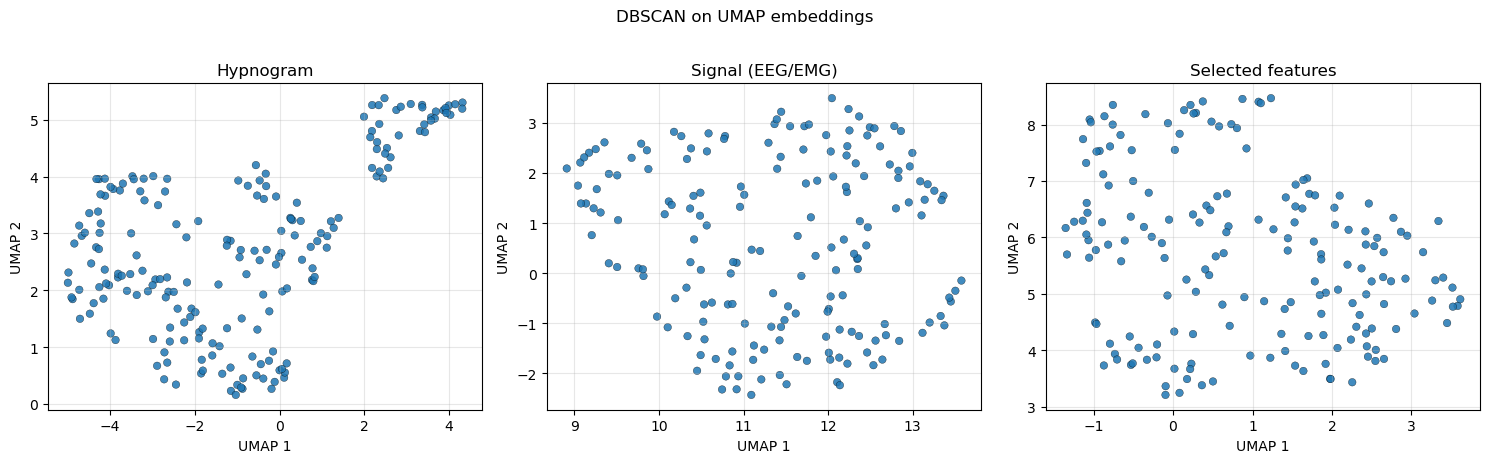

In [24]:

plot_dbscan_panels([
    (hypno_fit, hypno_labels, "Hypnogram"),
    (signal_fit, signal_labels, "Signal (EEG/EMG)"),
    (selected_fit, selected_labels, "Selected features"),
]) 